In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

In [53]:
application_test = pd.read_csv("home-credit-default-risk/application_test.csv")
application_train = pd.read_csv("home-credit-default-risk/application_train.csv")

In [54]:
#Wir versuchen erst mal application_train zu verstehen

In [55]:
application_train.shape

(4282, 122)

In [56]:
application_train.describe()

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
count,4282.000000,4282.000000,4282.000000,4.282000e+03,4.282000e+03,4282.000000,4.281000e+03,4282.000000,4282.000000,4282.000000,...,4281.000000,4281.000000,4281.000000,4281.000000,3693.000000,3693.000000,3693.000000,3693.000000,3693.00000,3693.000000
mean,102500.798459,0.078234,0.402616,1.675648e+05,5.993399e+05,27112.042854,5.398693e+05,0.020905,-16067.873424,65376.429472,...,0.006307,0.000467,0.000701,0.000467,0.008936,0.008936,0.036826,0.262930,0.27674,1.869483
std,1446.191132,0.268572,0.712273,9.738985e+04,4.033856e+05,14468.755288,3.710929e+05,0.014103,4330.914686,142549.077367,...,0.079175,0.021612,0.026466,0.021612,0.096954,0.132385,0.200886,0.919527,0.62910,1.840107
min,100002.000000,0.000000,0.000000,2.565000e+04,4.500000e+04,2596.500000,4.500000e+04,0.000938,-25160.000000,-15632.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000
25%,101242.750000,0.000000,0.000000,1.125000e+05,2.700000e+05,16583.625000,2.385000e+05,0.010006,-19651.750000,-2715.750000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000
50%,102514.500000,0.000000,0.000000,1.440000e+05,5.084955e+05,24990.750000,4.500000e+05,0.018850,-15861.000000,-1197.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,1.000000
75%,103748.750000,0.000000,1.000000,2.025000e+05,8.086500e+05,34627.500000,6.795000e+05,0.028663,-12463.000000,-281.250000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,3.000000
max,105006.000000,1.000000,7.000000,1.935000e+06,2.517300e+06,135936.000000,2.254500e+06,0.072508,-7705.000000,365243.000000,...,1.000000,1.000000,1.000000,1.000000,2.000000,4.000000,3.000000,16.000000,8.00000,11.000000


In [57]:
application_train["TARGET"].value_counts()

TARGET
0    3947
1     335
Name: count, dtype: int64

In [58]:
24825/282686

0.08781828601345662

In [59]:
categorialcols = application_train.select_dtypes(include=["object", "category"]).columns.tolist()
categorialcols

['NAME_CONTRACT_TYPE',
 'CODE_GENDER',
 'FLAG_OWN_CAR',
 'FLAG_OWN_REALTY',
 'NAME_TYPE_SUITE',
 'NAME_INCOME_TYPE',
 'NAME_EDUCATION_TYPE',
 'NAME_FAMILY_STATUS',
 'NAME_HOUSING_TYPE',
 'OCCUPATION_TYPE',
 'WEEKDAY_APPR_PROCESS_START',
 'ORGANIZATION_TYPE',
 'FONDKAPREMONT_MODE',
 'HOUSETYPE_MODE',
 'WALLSMATERIAL_MODE',
 'EMERGENCYSTATE_MODE']

In [60]:
NumericalCols = application_train.drop(columns=["TARGET"]).select_dtypes(include=["number"]).columns.tolist()
NumericalCols

['SK_ID_CURR',
 'CNT_CHILDREN',
 'AMT_INCOME_TOTAL',
 'AMT_CREDIT',
 'AMT_ANNUITY',
 'AMT_GOODS_PRICE',
 'REGION_POPULATION_RELATIVE',
 'DAYS_BIRTH',
 'DAYS_EMPLOYED',
 'DAYS_REGISTRATION',
 'DAYS_ID_PUBLISH',
 'OWN_CAR_AGE',
 'FLAG_MOBIL',
 'FLAG_EMP_PHONE',
 'FLAG_WORK_PHONE',
 'FLAG_CONT_MOBILE',
 'FLAG_PHONE',
 'FLAG_EMAIL',
 'CNT_FAM_MEMBERS',
 'REGION_RATING_CLIENT',
 'REGION_RATING_CLIENT_W_CITY',
 'HOUR_APPR_PROCESS_START',
 'REG_REGION_NOT_LIVE_REGION',
 'REG_REGION_NOT_WORK_REGION',
 'LIVE_REGION_NOT_WORK_REGION',
 'REG_CITY_NOT_LIVE_CITY',
 'REG_CITY_NOT_WORK_CITY',
 'LIVE_CITY_NOT_WORK_CITY',
 'EXT_SOURCE_1',
 'EXT_SOURCE_2',
 'EXT_SOURCE_3',
 'APARTMENTS_AVG',
 'BASEMENTAREA_AVG',
 'YEARS_BEGINEXPLUATATION_AVG',
 'YEARS_BUILD_AVG',
 'COMMONAREA_AVG',
 'ELEVATORS_AVG',
 'ENTRANCES_AVG',
 'FLOORSMAX_AVG',
 'FLOORSMIN_AVG',
 'LANDAREA_AVG',
 'LIVINGAPARTMENTS_AVG',
 'LIVINGAREA_AVG',
 'NONLIVINGAPARTMENTS_AVG',
 'NONLIVINGAREA_AVG',
 'APARTMENTS_MODE',
 'BASEMENTAREA_MODE',
 

In [61]:
application_train[categorialcols].describe()

,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,OCCUPATION_TYPE,WEEKDAY_APPR_PROCESS_START,ORGANIZATION_TYPE,FONDKAPREMONT_MODE,HOUSETYPE_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE
count,4282,4282,4282,4282,4267,4282,4282,4282,4282,2946,4282,4282,1405,2180,2153,2288
unique,2,2,2,2,7,5,5,5,6,18,7,57,4,3,7,2
top,Cash loans,F,N,Y,Unaccompanied,Working,Secondary / secondary special,Married,House / apartment,Laborers,TUESDAY,Business Entity Type 3,reg oper account,block of flats,Panel,No
freq,3862,2831,2846,2981,3457,2218,3071,2741,3805,742,742,968,1085,2142,933,2253


In [62]:
application_train.isnull().sum().sort_values(ascending=False)

COMMONAREA_MODE             2955
COMMONAREA_AVG              2955
COMMONAREA_MEDI             2955
NONLIVINGAPARTMENTS_MODE    2938
NONLIVINGAPARTMENTS_AVG     2938
                            ... 
NAME_FAMILY_STATUS             0
NAME_EDUCATION_TYPE            0
NAME_INCOME_TYPE               0
AMT_ANNUITY                    0
SK_ID_CURR                     0
Length: 122, dtype: int64

In [63]:
application_train[NumericalCols + ['TARGET']].corr()['TARGET'].drop("TARGET").abs().sort_values(ascending=False)

EXT_SOURCE_3                   0.211303
EXT_SOURCE_2                   0.176263
EXT_SOURCE_1                   0.158359
REGION_RATING_CLIENT_W_CITY    0.071936
NONLIVINGAPARTMENTS_MODE       0.070451
                                 ...   
FLAG_DOCUMENT_2                     NaN
FLAG_DOCUMENT_4                     NaN
FLAG_DOCUMENT_7                     NaN
FLAG_DOCUMENT_10                    NaN
FLAG_DOCUMENT_12                    NaN
Name: TARGET, Length: 105, dtype: float64

In [64]:
#es gab eine Fehlerhafte Zeile wo jemand seit 1000 Jahren angestellt war
application_train['DAYS_EMPLOYED'].replace(365243, np.nan, inplace=True)

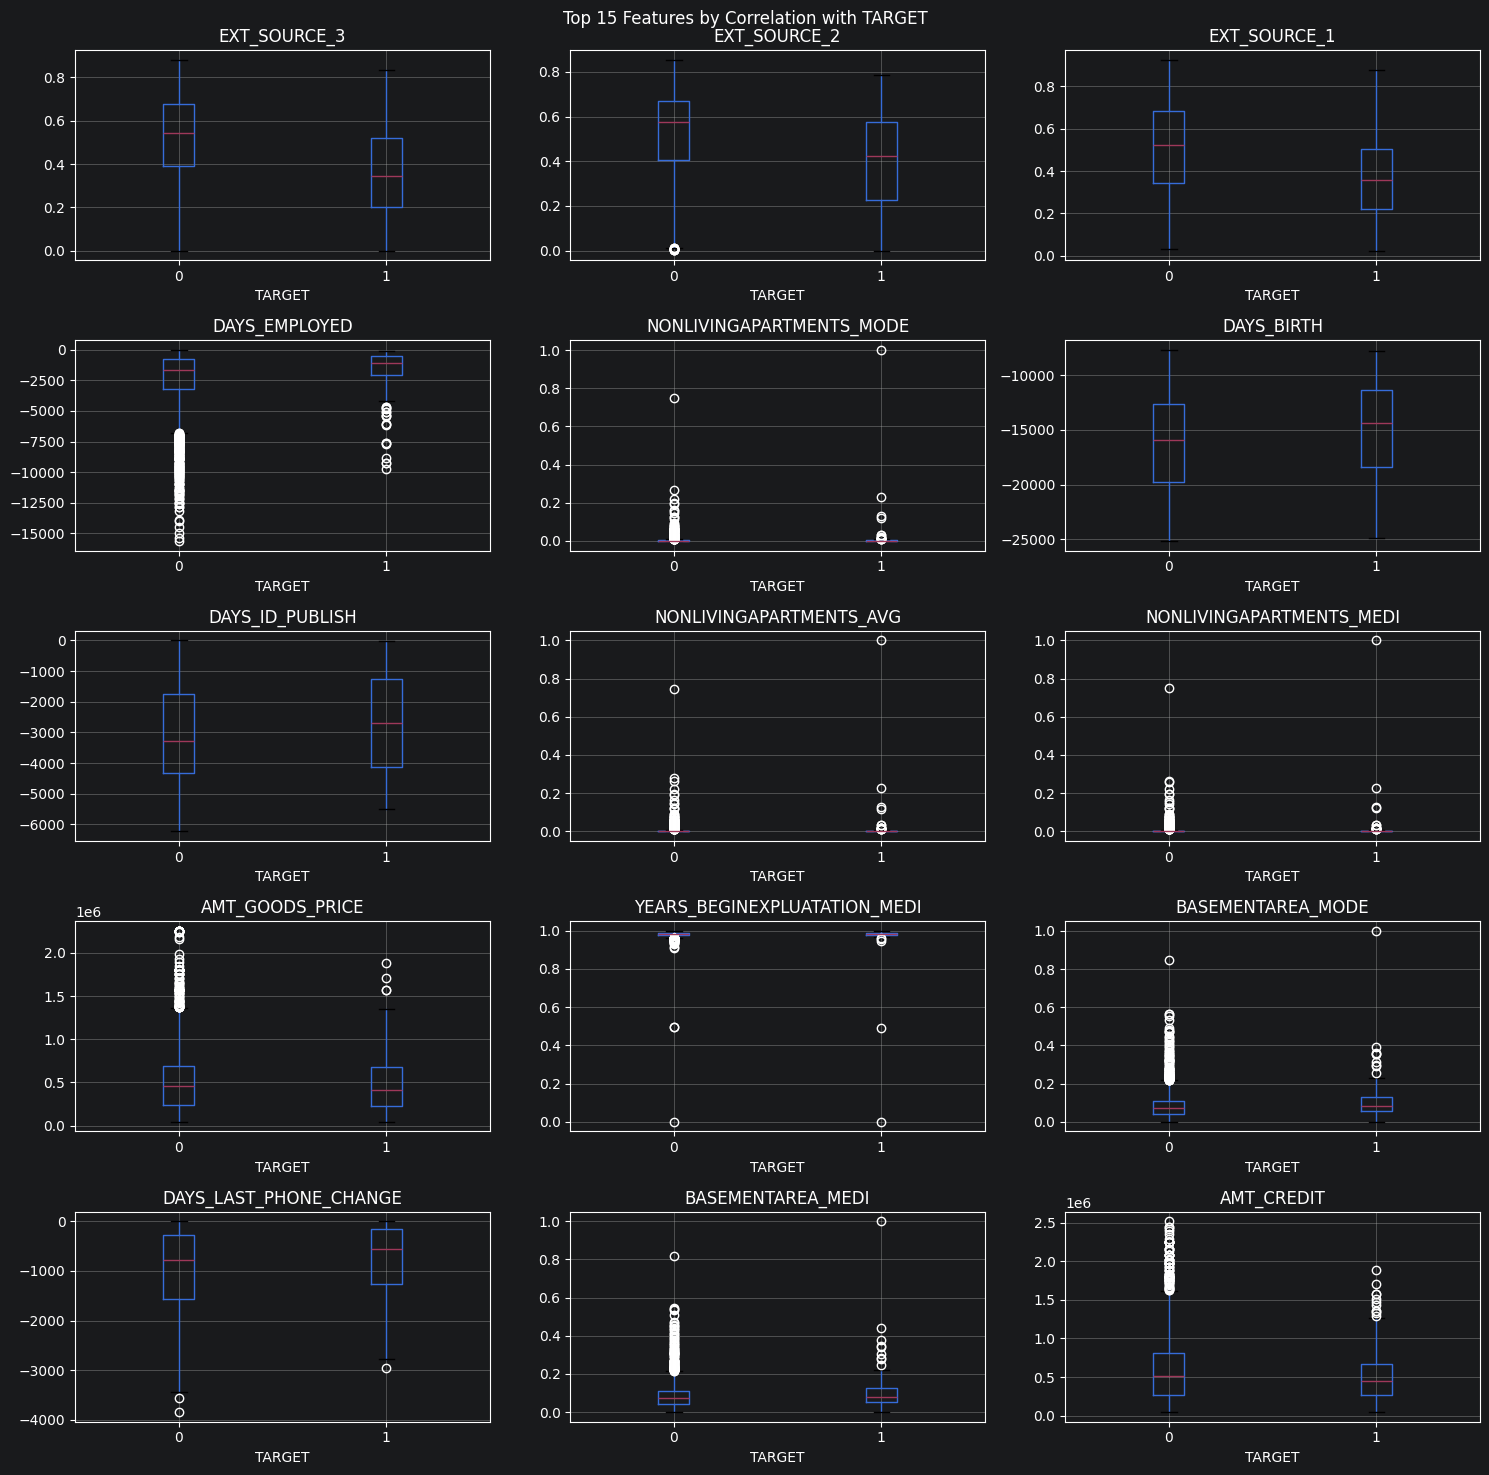

In [65]:
non_category = [col for col in NumericalCols if application_train[col].nunique() > 3]

top15 = (application_train[non_category + ['TARGET']]
         .corr()['TARGET']
         .drop('TARGET')
         .abs()
         .sort_values(ascending=False)
         .head(15)
         .index.tolist())

fig, axes = plt.subplots(5, 3, figsize=(15, 15))
axes = axes.flatten()

for i, col in enumerate(top15):
    application_train.boxplot(column=col, by='TARGET', ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel('TARGET')
plt.suptitle('Top 15 Features by Correlation with TARGET')
plt.tight_layout()

In [66]:
#Baseline model

In [67]:
missing = [c for c in NumericalCols + categorialcols if c not in X.columns]
print(missing)

[]


In [68]:
X = application_train.drop(columns="TARGET")
y = application_train["TARGET"]

num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(sparse_output=False, handle_unknown="ignore")),
])

preprocessor = ColumnTransformer([
    ("num", num_pipe, NumericalCols),
    ("cat", cat_pipe, categorialcols)
])
pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=100, solver="saga"))
])
pipe.fit(X, y)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(pipe, X, y, cv=cv, n_jobs=-1, scoring="roc_auc")

print(scores.mean())

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


0.7307294255008827


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The ma